# 01 - Analytical Black-Scholes Benchmark

The analytical formula supplies the reference price used to evaluate every numerical method. This notebook also checks whether the paper's values follow from its stated parameters.

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.option_pricing import black_scholes_price
from src.replication import build_paper_audit

print(f"Repository root: {ROOT}")

Repository root: c:\Users\user\Documents\GitHub\SVD replication paper


## Baseline scenario

Table 1 states (S_0=5), (K=5.5), (r=5\%\), and (sigma=25\%\). Maturities are three months, six months, and one year.

In [ ]:
S0, K, r, sigma = 5.0, 5.5, 0.05, 0.25
maturities = [0.25, 0.50, 1.00]
labels = ["3M", "6M", "1Y"]

baseline = pd.DataFrame({
    "maturity": labels,
    "standard_black_scholes": [
        black_scholes_price(S0, K, T, r, sigma, "call")
        for T in maturities
    ],
    "paper_reported_exact": [0.09737, 0.13606, 0.40131],
})
baseline["absolute_gap"] = abs(
    baseline["standard_black_scholes"] - baseline["paper_reported_exact"]
)
baseline.round(6)

,maturity,standard_black_scholes,paper_reported_exact,absolute_gap
0,3M,0.099025,0.09737,0.001655
1,6M,0.211289,0.13606,0.075229
2,1Y,0.401319,0.40131,0.000009


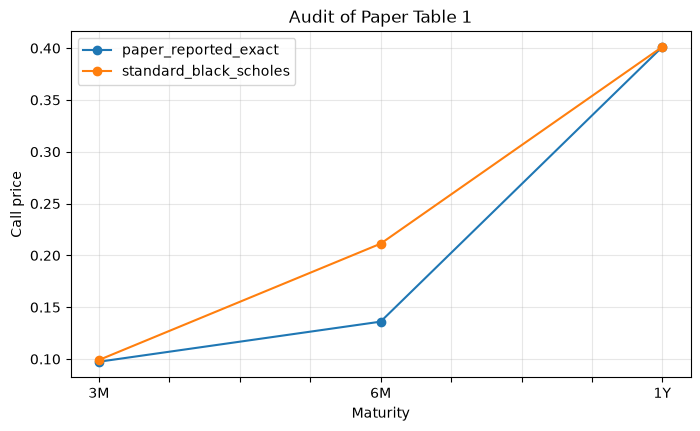

In [ ]:
ax = baseline.plot(
    x="maturity",
    y=["paper_reported_exact", "standard_black_scholes"],
    marker="o",
    figsize=(8, 4.5),
)
ax.set(title="Audit of Paper Table 1", xlabel="Maturity", ylabel="Call price")
ax.grid(alpha=0.3)
plt.show()

## Full four-table audit

For the two tables labelled as puts, both the standard call and put formula are calculated using the spot and strike stated in the paper's narrative. This allows the numerical values themselves to reveal which contract they resemble.

In [ ]:
audit = build_paper_audit()
audit.round(6)

,table,maturity,spot,strike,paper_exact,standard_call,standard_put,call_gap,put_gap,closest_standard_formula
0,Table 1 - call,3M,5.0,5.5,0.09737,0.099025,0.530703,0.001655,0.433333,call
1,Table 1 - call,6M,5.0,5.5,0.13606,0.211289,0.575494,0.075229,0.439434,call
2,Table 1 - call,1Y,5.0,5.5,0.40131,0.401319,0.633081,0.000009,0.231771,call
3,Table 2 - call,3M,7.0,7.5,0.18895,0.191559,0.598393,0.002609,0.409443,call
4,Table 2 - call,6M,7.0,7.5,0.24914,0.362185,0.677010,0.113045,0.427870,call
5,Table 2 - call,1Y,7.0,7.5,0.63791,0.637918,0.772139,0.000008,0.134229,call
6,Table 3 - labelled put,3M,5.5,5.0,0.63017,0.632073,0.069962,0.001903,0.560208,call
7,Table 3 - labelled put,6M,5.5,5.0,0.75512,0.758319,0.134869,0.003199,0.620251,call
8,Table 3 - labelled put,1Y,5.5,5.0,0.96525,0.965255,0.221402,0.000005,0.743848,call
9,Table 4 - labelled put,3M,7.5,7.0,0.72335,0.726200,0.139245,0.002850,0.584105,call


In [ ]:
audit.groupby(["table", "closest_standard_formula"]).size().rename("rows")

table                   closest_standard_formula
Table 1 - call          call                        3
Table 2 - call          call                        3
Table 3 - labelled put  call                        3
Table 4 - labelled put  call                        3
Name: rows, dtype: int64

## Interpretation

- The one-year values in all four tables are extremely close to standard call prices.
- The six-month values in the two call tables do not follow from the stated parameters.
- Every row of Tables 3 and 4 is closer to a call than a put, despite the put labels.

These are replication observations. They are retained rather than removed or fitted away.